# Элементы описательной статистики и подготовка данных.
# Часть 1. Выборочный метод в pandas
*Д.В. Чупраков, ВятГУ*

## 1. Загрузка данных

Импортируем библиотеку pandas:



In [1]:
import pandas as pd
import random


Для экспериментов будем использовать  наборы открытых данных портала [Работа России](https://trudvsem.ru/opendata/datasets) (https://trudvsem.ru/opendata/datasets).


Описание наборов открытых данных содержит [Атрибутивный состав наборов открытых данных портала «Работа России»](https://trudvsem.ru/information/resources/upload/opendata/datasets/Атрибутный_состав_наборов_открытых_данных_Портала_РвР_v5.1.docx)


Загрузим датасет "Вакансии всех регионов"

In [2]:
df_general = pd.read_csv('https://opendata.trudvsem.ru/csv/vacancy_4.csv',sep='|', dtype = str)

In [3]:
print(f'Число признаков: {len(df_general.columns)}\n')
df_general.head()

Число признаков: 78



,id,academic_degree,accommodation_capability,accommodation_type,additional_premium,additional_requirements,bonus_type,measure_type,busy_type,career_perspective,...,federalDistrictCode,industryBranchName,contactList,company_name,full_company_name,company_inn,company,languageKnowledge,hardSkills,softSkills
0,04195015-6997-11ee-bed0-ef6fdced905e,NaN,false,NaN,20,<p>Соц.пакет</p>,MONTHLY,PERCENT,Полная занятость,false,...,4,NaN,NaN,NaN,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""САМА...",6312110828,"{""companycode"":""1116312008340"",""email"":""info@s...",[],[],[]
1,0418ebb8-6b81-11ef-9774-d549be31d974,NaN,false,NaN,NaN,NaN,NaN,NaN,Временная,false,...,4,NaN,NaN,NaN,"МУНИЦИПАЛЬНОЕ БЮДЖЕТНОЕ УЧРЕЖДЕНИЕ ""УПРАВЛЕНИЕ...",6350013590,"{""companycode"":""1096350000383"",""email"":""mu-kin...",[],[],[]
2,0418d0d8-48f4-11ef-a95e-d7f294e00a65,NaN,false,NaN,NaN,NaN,NaN,NaN,Полная занятость,false,...,4,NaN,NaN,NaN,"ФЕДЕРАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ ""ВОЕННЫЙ КОМИС...",2128020325,"{""companycode"":""1022101149993"",""email"":""vkchuv...",[],[],[]
3,041511a2-7f9f-11ec-9bf6-bf2cfe8c828d,NaN,false,NaN,NaN,Ответственность,NaN,NaN,Полная занятость,false,...,4,NaN,NaN,NaN,ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ УЧРЕЖДЕНИЕ ЗДРАВООХР...,0265007932,"{""companycode"":""1020201934917"",""email"":""gb1pra...",[],[],[]
4,04143b02-759e-11ec-b378-bf2cfe8c828d,NaN,false,NaN,NaN,Сохраненное рабочее место<br/>Ответственность,NaN,NaN,Полная занятость,false,...,4,NaN,NaN,NaN,МУНИЦИПАЛЬНОЕ БЮДЖЕТНОЕ ДОШКОЛЬНОЕ ОБРАЗОВАТЕЛ...,2116820310,"{""companycode"":""1022102431570"",""email"":""ds_pur...",[],[],[]


 **Расшифровка некоторых полей**
 1. `id` - Идентификатор вакансии
 2. `vacancy_name` - Наименование вакансии
 3.	`code_profession` - Код профессии (из справочника профессий dict_profession поле code)
 4.	`code_professional_sphere` - Код профессиональной сферы (из справочника dict_professional_sphere поле code)
 5.	`professionalSphereName` - Наименование профессиональной сферы	(из справочника dict_professional_sphere поле name)
 6. `salary` - Заработная плата.
 7. `salary_min` – минимальный размер заработной платы;
 8. `salary_max` – максимальный размер заработной платы
 9. `social_protected_ids` - Группа соц. защищенности	(из справочника dict_social_protected поле id)
10. `languageKnowledge`	- Знание языков
11. `busy_type` - Тип занятости:
    - FULL – полная занятость;
    - PARTIAL – по совместительству;
    - PROJECT – временная;
    - PROBATION – стажировка;
    - SEASONAL – сезонная;
    - REMOTE – удалённая
12. `education` - Требования к уровню образования.
13. `education_speciality` – специальность по образованию.
14. `academicDegree` – ученая степень
15. `hardSkills` - Профессиональные навыки
16. `softSkills` - Гибкие навыки
17. `required_experience` - Требуемый опыт, лет
16.	`professionalSphereName` - Наименование профессиональной сферы	(из справочника dict_professional_sphere поле extrenal_id)
18.	`schedule_type`	График работы	Возможные значения:
    - FULL – полный рабочий день;
    - TURN – сменный график;
    - FLOAT – гибкий график;
    - WATCH – вахтовый метод;
    - IRREGULAR – ненормированный рабочий день;
    - PART_TIME – неполный рабочий день
19.	`other_vacancy_benefit` - Дополнительные бонусы

20.	`career_perspective` - Карьерный рост
21. `code_external_system` - Код внешней системы Возможные значения:
    - SKILLSNET;
    - CZN;
    - ABILYMPICS;
    - ENUM;
    - RESUME;
    - TEMPLATE
22.	`need_medcard` - Необходимость медицинской книжки
23. `source_type` - Тип источника вакансии Возможные значения:
    - RECRUITMENT_AGENCY – вакансия кадрового агентства;
    - COMPANY – вакансия работодателя;
    - CHAZ – вакансия ЧАЗ работодателя;
    - EMPLOYMENT_SERVICE – вакансия службы занятости;
    - HR_SERVICE – кадровая служба;
    - RPORTAL – вакансия портала по поиску работы;
    - FROM_ESIA – компания из ЕСИА;
    - INTERNET_RESOURCE – интернет-ресурс
24. `required_certificates` - Наличие сертификатов
25. `required_drive_license` - Требуемые водительские удостоверения Возможные значения: A, B, C, D, E
26. `retraining_capability` - Возможность переобучения.
27. `retraining_condition`	Условия переобучения
28.	`retraining_grant`	- Оплата во время обучения
29.	`retraining_grant_value` - Величина оплаты во время обучения
30. `transport_compensation` - Оплата транспортных расходов.
31.	`change_time` - Время изменения данных о вакансии.
32 	`contact_person` - ФИО для обращения по вопросам с вакансией
33.	`contact_source` - Источник контактных данных
34.	`company` - Информация о компании
35. `company_code` -
36. `company_inn` -
37. `company_business_size` - Размер компании Возможные значения:
    - SMALL;
    - BIG;
    - LARGE;
    - MIDDLE;
    - MICRO
38.	`full_company_name` - Полное наименование компании
39. `oknpo_code` - ОКНПО
40. `okso_code` - ОКСО
41. `date_modify` - Дата изменения
42 	`work_places` - 	Количество требуемых рабочих мест
43. `is_uzbekistan_recruitment` - Признак участия в организационном наборе по Узбекистану
44. 	`federalDistrictCode`	Код федерального округа
45. `industryBranchName` - Наименование отрасли	Код отрасли из справочника dict_industry_branch
46.	`published_date` - Дата публикации
47.	`accommodation_capability`	Возможность переезда
48. `accommodation_type` -  Тип предоставляемого работодателем жилья.Возможные значения:
    - NULL – нет;
    - FLAT – квартира;
    - ROOM – комната;
    - DORMITORY – общежитие;
    - HOUSE – дом
49. `foreign_workers_capability` - Возможность найма нерезидентов	        
50. `is_quoted` - Квотируемая вакансия. Наличие квот.
51. `date_create` - Дата создания вакансии
52. `deleted` - Признак удаления	Признак удаления вакансии
53. `visibility` - Видимость вакансии Возможные значения:
    - HIDDEN – скрыто;
    - VISIBLE_TO_ALL – видно всем
54.	`regionName`	Наименование региона
55.	`status` - Статус вакансии Возможные значения:
    - WAITING – ожидает подтверждения;
    - ACCEPTED – одобрено;
    - CHANGED – не опубликовано;
    - REJECTED – не одобрено
56. `position_requirements`	Должностные требования	Текстовое поле
57. `is_mobility_program` - Флаг включения в программу мобильности	Флаг включения в программу мобильности.
58. `is_moderated`	Признак модерации
59. `metro_ids`	- Идентификаторы станций метро из справочника dict_metro по полю metro_ids
60. `vacancy_address` - Адрес: Область, город
61. `vacancy_address_house` - Дом
62. `vacancy_address_additional_info` - Дополнительная адресная информация
63. `vacancy_address_latitude` - широта
64. `vacancy_address_longitude` -  долгота
65. `vacancy_address_code` - КЛАДР-код



Выберем интересующие поля:

- `id` - Идентификатор вакансии
- `vacancy_name` - Наименование вакансии
- `code_profession` - Код профессии (из справочника профессий dict_profession поле code)
- `code_professional_sphere` - Код профессиональной сферы (из справочника dict_professional_sphere поле code)
- `professionalSphereName` - Наименование профессиональной сферы	(из справочника dict_professional_sphere поле name)
- `salary_min` – минимальный размер заработной платы;
- `salary_max` – максимальный размер заработной платы
- `required_experience` - Требуемый опыт, лет
- `retraining_capability` - Возможность переобучения.
- `schedule_type`	График работы
- `busy_type` - Тип занятости
- `accommodation_capability`	Возможность переезда
- `education` - Требования к уровню образования
- `vacancy_address` - Адрес: Область, город
- `vacancy_address_house` - Дом
- `vacancy_address_code` - КЛАДР-код
- `regionName` - Наименование региона
- `deleted` - Признак удаления	Признак удаления вакансии
- `visibility` - Видимость вакансии Возможные значения:
- `status` - Статус вакансии Возможные значения:



In [4]:
feats = ['id', 'vacancy_name',
         'code_profession','code_professional_sphere','professionalSphereName',
         'schedule_type',
         'salary_min', 'salary_max',
         'busy_type', 'accommodation_capability',
         'education', 'required_experience','retraining_capability',
         'vacancy_address_code', 'regionName',
         'deleted', 'visibility', 'status']

df = df_general[feats]

In [5]:
df_general.shape

(120648, 78)

In [6]:
df.shape

(120648, 18)

In [7]:
print(f'Объем генеральной совокупности: {df.shape[0]} единиц')

Объем генеральной совокупности: 120648 единиц


In [8]:
df.head(3)

,id,vacancy_name,code_profession,code_professional_sphere,professionalSphereName,schedule_type,salary_min,salary_max,busy_type,accommodation_capability,education,required_experience,retraining_capability,vacancy_address_code,regionName,deleted,visibility,status
0,04195015-6997-11ee-bed0-ef6fdced905e,Плотник 5 разряда,166719,Communal,"ЖКХ, эксплуатация",Полный рабочий день,46462,46462,Полная занятость,false,Среднее профессиональное,1,NaN,63000001000076400,Самарская область,false,VISIBLE_TO_ALL,ACCEPTED
1,0418ebb8-6b81-11ef-9774-d549be31d974,рабочий,175436,WorkingSpecialties,Рабочие специальности,Неполный рабочий день,19300,19300,Временная,false,Не указано,0,NaN,63000010000008000,Самарская область,false,VISIBLE_TO_ALL,ACCEPTED
2,0418d0d8-48f4-11ef-a95e-d7f294e00a65,Старший помощник военного комиссара (по финанс...,203369,AccountingTaxesManagement,"Бухгалтерия, налоги, управленческий учет",Полный рабочий день,25000,0,Полная занятость,false,Высшее,0,NaN,21006000001001600,Чувашская Республика - Чувашия,false,VISIBLE_TO_ALL,ACCEPTED


## 2. Формирование выборки

### 2.1 Случайная выборка

In [15]:
df_sample = df.sample(n=10, replace=False)

In [16]:
df_sample

,id,vacancy_name,code_profession,code_professional_sphere,professionalSphereName,schedule_type,salary_min,salary_max,busy_type,accommodation_capability,education,required_experience,retraining_capability,vacancy_address_code,regionName,deleted,visibility,status
95391,df221298-7653-11ef-8c44-cb26dff57dd7,Тракторист-машинист сельскохозяйственного прои...,192056,Agricultural,"Сельское хозяйство, экология, ветеринария",Ненормированный рабочий день,30000,30000,Полная занятость,false,Среднее,0,NaN,18008000036000200,Удмуртская Республика,false,VISIBLE_TO_ALL,ACCEPTED
92803,cf94ec70-6f38-11ef-8a30-d549be31d974,Токарь (токарь-универсал),191496,Industry,Производство,Полный рабочий день,73100,89400,Полная занятость,false,Среднее профессиональное,1,NaN,63028000000064300,Самарская область,false,VISIBLE_TO_ALL,ACCEPTED
24497,b7626218-7689-11ef-b8ae-e7d0d2cf29b1,учитель русского языка и литературы,272458,Education,"Образование, наука",Полный рабочий день,20000,25000,Полная занятость,false,Высшее,0,NaN,58011001000004700,Пензенская область,false,VISIBLE_TO_ALL,ACCEPTED
52479,0f9219d5-9307-11ec-9f92-57fc951f3846,Заместитель начальника по эксплуатации автомоб...,222482,BuldindRealty,"Строительство, ремонт, стройматериалы, недвижи...",Полный рабочий день,43968,0,Полная занятость,false,Высшее,3,NaN,12004001000001600,Республика Марий Эл,false,VISIBLE_TO_ALL,ACCEPTED
66927,e2110ea5-5393-11ed-ad93-ed9942adf613,Инженер-конструктор (схемотехник),424935,MechanicalEngineering,Машиностроение,Полный рабочий день,32900,75900,Полная занятость,false,Высшее,1,NaN,43000001000032300,Кировская область,false,VISIBLE_TO_ALL,ACCEPTED
23478,a6dffc75-94e6-11ee-8a12-d549be31d974,Грузчик,117680,Sales,"Продажи, закупки, снабжение, торговля",Полный рабочий день,20000,0,Полная занятость,false,Не указано,0,NaN,6401000000100,Саратовская область,false,VISIBLE_TO_ALL,ACCEPTED
43716,88ce5858-6e78-11ef-b387-bb4c34bddc95,Специалист по социальной политике,265416,DeskWork,"Административная работа, секретариат, АХО",Полный рабочий день,23196,23196,Полная занятость,false,Высшее,3,NaN,73001000002001600,Ульяновская область,false,VISIBLE_TO_ALL,ACCEPTED
15521,71170f65-100d-11ee-9ec8-7bf0923e021e,Педагог дополнительного образования детей и вз...,272443,Education,"Образование, наука",Полный рабочий день,19242,25000,Полная занятость,false,Высшее,0,NaN,73009000016004200,Ульяновская область,false,VISIBLE_TO_ALL,ACCEPTED
34270,922276d5-9ad0-11ec-92fd-550ed7335bbe,Контролер ОТК,129584,Industry,Производство,Сменный график,35000,0,Полная занятость,false,Среднее профессиональное,1,NaN,59000012000032500,Пермский край,false,VISIBLE_TO_ALL,ACCEPTED
98504,359f4135-8f14-11ec-a69c-4febb26dc4ec,Слесарь по эксплуатации и ремонту газового обо...,184492,WorkingSpecialties,Рабочие специальности,Полный рабочий день,24000,27000,Полная занятость,false,Среднее профессиональное,1,NaN,43000001000022500,Кировская область,false,VISIBLE_TO_ALL,ACCEPTED


In [17]:
df_sample = df.sample(frac = 0.1) # 10%

In [18]:
df_sample.shape

(12065, 18)

### 2.2 Механическая выборка

Выберем каждую вторую запись

In [19]:
df.iloc[0:10:2,:]

,id,vacancy_name,code_profession,code_professional_sphere,professionalSphereName,schedule_type,salary_min,salary_max,busy_type,accommodation_capability,education,required_experience,retraining_capability,vacancy_address_code,regionName,deleted,visibility,status
0,04195015-6997-11ee-bed0-ef6fdced905e,Плотник 5 разряда,166719,Communal,"ЖКХ, эксплуатация",Полный рабочий день,46462,46462,Полная занятость,false,Среднее профессиональное,1,NaN,63000001000076400,Самарская область,false,VISIBLE_TO_ALL,ACCEPTED
2,0418d0d8-48f4-11ef-a95e-d7f294e00a65,Старший помощник военного комиссара (по финанс...,203369,AccountingTaxesManagement,"Бухгалтерия, налоги, управленческий учет",Полный рабочий день,25000,0,Полная занятость,false,Высшее,0,NaN,21006000001001600,Чувашская Республика - Чувашия,false,VISIBLE_TO_ALL,ACCEPTED
4,04143b02-759e-11ec-b378-bf2cfe8c828d,Кастелянша,127201,Industry,Производство,Сменный график,19242,19242,Полная занятость,false,Среднее,0,NaN,2100000000000,Чувашская Республика - Чувашия,false,VISIBLE_TO_ALL,ACCEPTED
6,0412ce86-f8e6-11eb-8a7b-3bfa22f2d66b,Оператор упаковочной линии,392974,Food,Пищевая промышленность,Полный рабочий день,30000,0,Полная занятость,false,Не указано,0,NaN,1602100006400,Республика Татарстан (Татарстан),false,VISIBLE_TO_ALL,ACCEPTED
8,04105ce5-d766-11ec-b20f-d768660431c4,Дорожный рабочий,118895,Transport,"Транспорт, автобизнес, логистика, склад, ВЭД",Сменный график,25900,0,Полная занятость,false,Не указано,0,NaN,63017001000002900,Самарская область,false,VISIBLE_TO_ALL,ACCEPTED


а теперь каждую сотую

In [20]:

df_sample = df.iloc[::100, :]


In [21]:
df_sample.shape

(1207, 18)

### 2.3 Стратифицированная выборка

In [22]:
df['regionName'].unique()

array(['Самарская область', 'Чувашская Республика - Чувашия',
       'Республика Башкортостан', 'Республика Татарстан (Татарстан)',
       'Саратовская область', 'Оренбургская область', 'Пермский край',
       'Ульяновская область', 'Кировская область', 'Пензенская область',
       'Республика Марий Эл', 'Нижегородская область',
       'Республика Мордовия', 'Удмуртская Республика', nan], dtype=object)

In [23]:
df[df['regionName']=='Пензенская область'].sample(frac = 0.1)

,id,vacancy_name,code_profession,code_professional_sphere,professionalSphereName,schedule_type,salary_min,salary_max,busy_type,accommodation_capability,education,required_experience,retraining_capability,vacancy_address_code,regionName,deleted,visibility,status
87373,bca74955-ed71-11ec-aeb7-d768660431c4,Воспитатель группы продленного дня,272443,Education,"Образование, наука",Полный рабочий день,19242,25000,Полная занятость,false,Не указано,0,NaN,58000001000098800,Пензенская область,false,VISIBLE_TO_ALL,ACCEPTED
80660,ed9c13d8-3458-11ef-bf8c-cb26dff57dd7,Лаборант химического анализа,236907,ElectricpowerIndustry,Электроэнергетика,Полный рабочий день,23071,34000,Полная занятость,false,Не указано,0,NaN,58000003000023300,Пензенская область,false,VISIBLE_TO_ALL,ACCEPTED
119168,e8caa1d8-7744-11ef-88a9-29eee561bb17,Мастер (участок обслуживания механо-технологич...,237967,ChemicalAndFuelIndustry,"Химическая, нефтехимическая, топливная промышл...",Ненормированный рабочий день,60235,67342,Полная занятость,false,Среднее профессиональное,1,NaN,5800600003000,Пензенская область,false,VISIBLE_TO_ALL,ACCEPTED
95299,ff479040-7a4b-11ee-be6b-cb26dff57dd7,Ведущий инженер по охране труда,224469,HumanRecruitment,"Кадровая служба, управление персоналом",Полный рабочий день,29000,0,Полная занятость,false,Не указано,0,NaN,58000001000088400,Пензенская область,false,VISIBLE_TO_ALL,ACCEPTED
99353,c36389f1-770f-11ef-8511-25abf1fceba2,Оператор call-центра,NaN,Sales,"Продажи, закупки, снабжение, торговля",Гибкий график,0,0,Полная занятость,false,Не указано,NaN,NaN,5800000100000,Пензенская область,false,VISIBLE_TO_ALL,ACCEPTED
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15231,7a4a0025-d9ed-11ed-ad66-61ac0511d36c,буфетчица,181121,Medicine,Здравоохранение и социальное обеспечение,Сменный график,24000,0,Полная занятость,false,Среднее профессиональное,0,NaN,58000001000079100,Пензенская область,false,VISIBLE_TO_ALL,ACCEPTED
56590,1f045561-6d00-11ef-8511-25abf1fceba2,Продавец-кассир,NaN,Sales,"Продажи, закупки, снабжение, торговля",Полный рабочий день,27900,37700,Полная занятость,false,Среднее,NaN,NaN,58004000001005500,Пензенская область,false,VISIBLE_TO_ALL,ACCEPTED
91576,d28453a8-66c6-11ef-b6c5-e7d0d2cf29b1,учитель русского языка и литературы,258130,Education,"Образование, наука",Полный рабочий день,19242,19242,Полная занятость,false,Не указано,0,NaN,5802800003300,Пензенская область,false,VISIBLE_TO_ALL,ACCEPTED
5568,66e4f6e5-77ed-11ee-90e4-e7d0d2cf29b1,Агроном,200407,Agricultural,"Сельское хозяйство, экология, ветеринария",Полный рабочий день,57500,0,Временная,false,Высшее,3,NaN,58005001000004300,Пензенская область,false,VISIBLE_TO_ALL,ACCEPTED


In [24]:
# Склеим два региона
df1 = df[df['regionName']== 'Пензенская область'].sample(frac=0.1)
df2 = df[df['regionName']== 'Кировская область'].sample(frac=0.1)
df32 = df[df['regionName']== 'Пермский край'].sample(frac=0.1)
pd.concat([df1,df2],axis=0)


,id,vacancy_name,code_profession,code_professional_sphere,professionalSphereName,schedule_type,salary_min,salary_max,busy_type,accommodation_capability,education,required_experience,retraining_capability,vacancy_address_code,regionName,deleted,visibility,status
116516,63919747-53d5-11ef-87f1-d549be31d974,Инженер-энергетик,228737,Industry,Производство,Полный рабочий день,51000,0,Полная занятость,false,Высшее,1,NaN,58000001000022700,Пензенская область,false,VISIBLE_TO_ALL,ACCEPTED
57813,41390298-548a-11ef-87f1-d549be31d974,контролер,454178,Safety,"Безопасность, службы охраны",Сменный график,24000,35000,Полная занятость,false,Не указано,0,true,58000001000028500,Пензенская область,false,VISIBLE_TO_ALL,ACCEPTED
116200,741c62b5-8273-11ec-b19e-57fc951f3846,слесарь-сантехник 6 разряд,185601,Communal,"ЖКХ, эксплуатация",Сменный график,19426,0,Частичная занятость,false,Не указано,0,NaN,58000001000035700,Пензенская область,false,VISIBLE_TO_ALL,ACCEPTED
94802,f88571d1-6cff-11ef-8511-25abf1fceba2,Продавец-кассир,NaN,Sales,"Продажи, закупки, снабжение, торговля",Полный рабочий день,29000,39150,Полная занятость,false,Среднее,NaN,NaN,58000001000101200,Пензенская область,false,VISIBLE_TO_ALL,ACCEPTED
77573,f6f8dba2-4bb9-11ec-b40f-bf2cfe8c828d,Инженер-электрик,428669,Industry,Производство,Полный рабочий день,45000,50000,Полная занятость,false,Высшее,0,NaN,5800000000000,Пензенская область,false,VISIBLE_TO_ALL,ACCEPTED
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60749,450d09e5-bf2d-11ee-b974-cb26dff57dd7,Продавец-кассир,173534,Sales,"Продажи, закупки, снабжение, торговля",Сменный график,31000,0,Полная занятость,false,Среднее общее,0,NaN,43000004000007400,Кировская область,false,VISIBLE_TO_ALL,ACCEPTED
57511,42193a95-2ea3-11ed-85de-35178352af9b,машинист (кочегар) котельной,137862,Communal,"ЖКХ, эксплуатация",Полный рабочий день,22129,24000,Сезонная,false,Не указано,0,NaN,43017000068001300,Кировская область,false,VISIBLE_TO_ALL,ACCEPTED
73803,eea4ac85-d831-11ed-861d-17f530626801,Оператор технологического оборудования,192179,Industry,Производство,Сменный график,45000,0,Полная занятость,false,Не указано,0,NaN,43000001000059600,Кировская область,false,VISIBLE_TO_ALL,ACCEPTED
69117,c85d3808-6113-11ef-baff-d549be31d974,Техник по эксплуатации оборудования газовых об...,269277,ServiceMaintenance,"Услуги населению, сервисное обслуживание",Полный рабочий день,29000,0,Полная занятость,false,Среднее профессиональное,0,NaN,43000004000012100,Кировская область,false,VISIBLE_TO_ALL,ACCEPTED


In [34]:
# Склеим все регионы циклом
df_sample = pd.DataFrame(columns = df.columns)
regions = df['regionName'].unique()
for region in regions:
  df1 = df[df['regionName']== region].sample(frac=0.1)
  df_sample = pd.concat([df_sample,df1],axis=0)


1. Инициализация пустого DataFrame:

   df_sample = pd.DataFrame(columns = df.columns)

   Эта строка создает пустой DataFrame `df_sample`, который имеет те же столбцы, что и исходный DataFrame `df`. В начале в нем нет данных.

2. Получение уникальных значений региона:

   regions = df['regionName'].unique()

   Здесь мы извлекаем уникальные значения из столбца 'regionName' DataFrame `df` и сохраняем их в переменной `regions`. Это список всех уникальных регионов в вашем наборе данных.

3. Выборка данных для каждого региона:

   for region in regions:
       df1 = df[df['regionName'] == region].sample(frac=0.1)
       df_sample = pd.concat([df_sample, df1], axis=0)

   - Этот цикл `for` проходит по каждому уникальному региону из списка `regions`.
   - Внутри цикла выполняется фильтрация: `df[df['regionName'] == region]` выбирает только те строки, где значение в столбце 'regionName' соответствует текущему региону.
   - Затем `.sample(frac=0.1)` случайным образом выбирает 10% из отфильтрованных строк для текущего региона и сохраняет их в переменной `df1`.
   - Наконец, `pd.concat([df_sample, df1], axis=0)` объединяет (конкатенирует) новый DataFrame `df1` с уже существующим `df_sample` по вертикали (по строкам).

В результате выполнения этого кода в `df_sample` получится новый DataFrame, который будет содержать случайно выбранные 10% данных для каждого уникального региона из исходного DataFrame `df`. Это позволяет получить репрезентативную выборку данных для дальнейшего анализа.

In [35]:
df_sample

,id,vacancy_name,code_profession,code_professional_sphere,professionalSphereName,schedule_type,salary_min,salary_max,busy_type,accommodation_capability,education,required_experience,retraining_capability,vacancy_address_code,regionName,deleted,visibility,status
100731,723fb067-3591-11ed-a6ad-791a818bdadb,врач по медицинской профилактике,204484,Medicine,Здравоохранение и социальное обеспечение,Полный рабочий день,40000,0,Полная занятость,false,Высшее,0,NaN,63000001000014400,Самарская область,false,VISIBLE_TO_ALL,ACCEPTED
57831,412999b6-8b2c-11ec-a92f-57fc951f3846,уборщик производственных и служебных помещений,192588,Education,"Образование, наука",Полный рабочий день,20000,20000,Полная занятость,false,Среднее,0,NaN,63000001000073500,Самарская область,false,VISIBLE_TO_ALL,ACCEPTED
26054,b9506da8-32b5-11ef-a2f9-cb26dff57dd7,Дворник,117869,Transport,"Транспорт, автобизнес, логистика, склад, ВЭД",Полный рабочий день,30000,0,Полная занятость,false,Не указано,0,NaN,63000007000006200,Самарская область,false,VISIBLE_TO_ALL,ACCEPTED
9133,5833c105-dfee-11ec-b0c5-d768660431c4,Официант,163994,Food,Пищевая промышленность,Сменный график,31350,31350,Полная занятость,false,Среднее,0,NaN,6302200005300,Самарская область,false,VISIBLE_TO_ALL,ACCEPTED
77727,f67bc7c5-f722-11ee-b4ac-d549be31d974,продавец-кассир,173534,Sales,"Продажи, закупки, снабжение, торговля",Полный рабочий день,28000,0,Полная занятость,false,Не указано,0,NaN,63016000012001500,Самарская область,false,VISIBLE_TO_ALL,ACCEPTED
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116774,8e468b35-acfb-11ed-99ab-17f530626801,Слесарь-сантехник,185601,MechanicalEngineering,Машиностроение,Сменный график,50000,0,Полная занятость,false,Среднее,0,NaN,18000003000006900,Удмуртская Республика,false,VISIBLE_TO_ALL,ACCEPTED
116149,7536da55-db80-11ee-9886-cb26dff57dd7,Сетевой и системный администратор,400644,MechanicalEngineering,Машиностроение,Полный рабочий день,44900,44900,Полная занятость,false,Среднее профессиональное,3,NaN,1800000000000,Удмуртская Республика,false,VISIBLE_TO_ALL,ACCEPTED
73238,bbca6428-74e9-11ef-ae3d-cb26dff57dd7,Оператор установки бестарного хранения сырья,161113,Food,Пищевая промышленность,Сменный график,40000,45000,Полная занятость,false,Не указано,0,NaN,18000002000004300,Удмуртская Республика,false,VISIBLE_TO_ALL,ACCEPTED
26492,b4555d28-75ad-11ef-bc0d-b905f621e080,водитель,114428,StateServices,"Государственная служба, некоммерческие организ...",Полный рабочий день,29000,29000,Полная занятость,false,Не указано,3,NaN,18003000001009100,Удмуртская Республика,false,VISIBLE_TO_ALL,ACCEPTED


In [26]:
# Короткий способ формирования стратифицированной выборки
df_sample = df.groupby('regionName', group_keys=False).apply(lambda x: x.sample(frac=0.1))

In [27]:
df_sample

,id,vacancy_name,code_profession,code_professional_sphere,professionalSphereName,schedule_type,salary_min,salary_max,busy_type,accommodation_capability,education,required_experience,retraining_capability,vacancy_address_code,regionName,deleted,visibility,status
59354,40db2088-295b-11ef-9122-cb26dff57dd7,Социальный работник,265276,Medicine,Здравоохранение и социальное обеспечение,Полный рабочий день,30000,0,Полная занятость,false,Среднее общее,0,NaN,4300000104400,Кировская область,false,VISIBLE_TO_ALL,ACCEPTED
17294,025bc595-fdff-11ed-bfbb-e59dc4777783,Техник по охранно-пожарной сигнализации,269277,Safety,"Безопасность, службы охраны",Полный рабочий день,50000,0,Полная занятость,false,Среднее профессиональное,0,NaN,43000001000013600,Кировская область,false,VISIBLE_TO_ALL,ACCEPTED
6058,54fa9c45-a6f2-11ed-99ab-17f530626801,Помощник воспитателя,168447,Education,"Образование, наука",Полный рабочий день,23000,23000,Полная занятость,false,Не указано,0,NaN,43000001000038500,Кировская область,false,VISIBLE_TO_ALL,ACCEPTED
112289,1f8b8875-ece8-11ee-8908-e7d0d2cf29b1,Пекарь,164728,Restaurants,"Туризм, гостиницы, рестораны",Полный рабочий день,38000,45000,Полная занятость,false,Среднее профессиональное,1,NaN,43000001000026900,Кировская область,false,VISIBLE_TO_ALL,ACCEPTED
53704,2e2c95f0-17a5-11ed-a77b-791a818bdadb,Кочегар сушильных печей и барабанов,131601,Forest,"Лесная, деревообрабатывающая, целлюлозно-бумаж...",Сменный график,23000,0,Полная занятость,false,Среднее,0,NaN,43000001000023100,Кировская область,false,VISIBLE_TO_ALL,ACCEPTED
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20413,a8f56815-e6ad-11ee-b732-d549be31d974,медицинская сестра по физиотерапии,242734,Medicine,Здравоохранение и социальное обеспечение,Полный рабочий день,40000,0,Полная занятость,false,Среднее профессиональное,0,NaN,21002000039000600,Чувашская Республика - Чувашия,false,VISIBLE_TO_ALL,ACCEPTED
75340,d132dee8-7102-11ef-90c3-e7d0d2cf29b1,Специалист в области библиотечно-информационно...,203161,Culture,"Искусство, культура и развлечения",Неполный рабочий день,19242,0,Частичная занятость,false,Не указано,0,NaN,21010000001000900,Чувашская Республика - Чувашия,false,VISIBLE_TO_ALL,ACCEPTED
35043,8cf27915-ca41-11ee-b48c-bb4c34bddc95,Уборщик служебных помещений,192588,Education,"Образование, наука",Полный рабочий день,0,30000,Полная занятость,false,Среднее,0,NaN,21000001000005300,Чувашская Республика - Чувашия,false,VISIBLE_TO_ALL,ACCEPTED
31678,9b8e7e05-aadb-11ed-99ab-17f530626801,Главный специалист-эксперт юридического отдела,208894,Jurisprudence,Юриспруденция,Полный рабочий день,23000,30000,Полная занятость,false,Высшее,0,NaN,21017000001001200,Чувашская Республика - Чувашия,false,VISIBLE_TO_ALL,ACCEPTED


### 2.4 Серийная выборка

In [29]:
el = random.choice(df['regionName'].unique())
df_sample_serial = df[df['regionName']== el]

1. Случайный выбор региона:
```python
   el = random.choice(df['regionName'].unique())
```
   Эта строка кода выполняет следующее:
   - `df['regionName'].unique()` извлекает все уникальные значения из столбца 'regionName' DataFrame `df`. Это создает массив, содержащий все разные названия регионов.
   - `random.choice(...)` случайным образом выбирает одно значение из этого массива уникальных названий регионов и сохраняет его в переменной `el`. Таким образом, `el` будет содержать одно случайное название региона.

2. Фильтрация данных по выбранному региону:
```python
   df_sample_serial = df[df['regionName'] == el]
```
   Эта строка кода делает следующее:
   - `df[df['regionName'] == el]` фильтрует DataFrame `df`, оставляя только те строки, где значение в столбце 'regionName' совпадает со случайно выбранным регионом `el`.
   - Результат фильтрации сохраняется в переменной `df_sample_serial`. В итоге `df_sample_serial` будет содержать все строки из `df`, относящиеся к случайно выбранному региону.

Таким образом, в результате выполнения этого кода вы получите DataFrame `df_sample_serial`, который содержит все данные только для одного случайно выбранного региона из исходного DataFrame `df`.

In [30]:
df_sample_serial.head()

,id,vacancy_name,code_profession,code_professional_sphere,professionalSphereName,schedule_type,salary_min,salary_max,busy_type,accommodation_capability,education,required_experience,retraining_capability,vacancy_address_code,regionName,deleted,visibility,status
35,0401dd28-6ac4-11ef-b215-d549be31d974,Уборщик служебных помещений,192588,Education,"Образование, наука",Полный рабочий день,19242,19242,Полная занятость,false,Не указано,0,NaN,13000003000021400,Республика Мордовия,false,VISIBLE_TO_ALL,ACCEPTED
115,03bf8b50-3e82-11ef-bdd6-cb26dff57dd7,рабочий по кмплексному обслуживанию здания,175440,WorkingSpecialties,Рабочие специальности,Полный рабочий день,22000,0,Полная занятость,false,Не указано,0,NaN,13000001017001200,Республика Мордовия,false,VISIBLE_TO_ALL,ACCEPTED
132,03ad4ec5-1bee-11ee-b431-dd0276383d19,специалист по охране труда,265416,Industry,Производство,Полный рабочий день,44000,0,Полная занятость,false,Не указано,0,NaN,13000001000013400,Республика Мордовия,false,VISIBLE_TO_ALL,ACCEPTED
146,039ef2e5-b801-11ed-9146-91f5d381286a,Музыкальный руководитель,242556,Education,"Образование, наука",Полный рабочий день,21400,0,Временная,false,Среднее профессиональное,0,NaN,1300000000000,Республика Мордовия,false,VISIBLE_TO_ALL,ACCEPTED
153,03998bc5-6009-11ed-b6c5-91f5d381286a,Уборщик служебных помещений,192588,Medicine,Здравоохранение и социальное обеспечение,Полный рабочий день,19242,0,Полная занятость,false,Не указано,0,NaN,13000001000002500,Республика Мордовия,false,VISIBLE_TO_ALL,ACCEPTED


### 2.6. Предварительная фильтрация

1. Исключим удаленные и отклоненные вакансии
2. Удалим записи с пустыми значениями

In [36]:
df_sample = df_sample.drop(columns=['deleted'])

In [37]:
df_sample.shape

(11947, 17)

In [38]:
df_sample['status'].unique()

array(['ACCEPTED', 'WAITING', 'REJECTED', 'CHANGED'], dtype=object)

In [39]:
df_sample[df_sample['status']=='REJECTED'].shape

(16, 17)

In [40]:
df_sample = df_sample[df_sample['status'] != 'REJECTED']

In [41]:
df_sample['status'].unique()

array(['ACCEPTED', 'WAITING', 'CHANGED'], dtype=object)

In [42]:
df_sample = df_sample.drop(columns=['status','deleted'], errors='ignore')

In [43]:
df_sample.shape

(11931, 16)

## 3. Кодирование признаков

На этом этапе:
1. Cопоставим правильные типы признакам.
2. Определим шкалы
3. Выделим dummy-признаки (фиктивные переменные)
4. Выполним One-Hot кодирование для качественных признаков с конечным числом состояний



In [44]:
df.columns

Index(['id', 'vacancy_name', 'code_profession', 'code_professional_sphere',
       'professionalSphereName', 'schedule_type', 'salary_min', 'salary_max',
       'busy_type', 'accommodation_capability', 'education',
       'required_experience', 'retraining_capability', 'vacancy_address_code',
       'regionName', 'deleted', 'visibility', 'status'],
      dtype='object')

In [45]:
df_sample.head(3)

,id,vacancy_name,code_profession,code_professional_sphere,professionalSphereName,schedule_type,salary_min,salary_max,busy_type,accommodation_capability,education,required_experience,retraining_capability,vacancy_address_code,regionName,visibility
100731,723fb067-3591-11ed-a6ad-791a818bdadb,врач по медицинской профилактике,204484,Medicine,Здравоохранение и социальное обеспечение,Полный рабочий день,40000,0,Полная занятость,false,Высшее,0,NaN,63000001000014400,Самарская область,VISIBLE_TO_ALL
57831,412999b6-8b2c-11ec-a92f-57fc951f3846,уборщик производственных и служебных помещений,192588,Education,"Образование, наука",Полный рабочий день,20000,20000,Полная занятость,false,Среднее,0,NaN,63000001000073500,Самарская область,VISIBLE_TO_ALL
26054,b9506da8-32b5-11ef-a2f9-cb26dff57dd7,Дворник,117869,Transport,"Транспорт, автобизнес, логистика, склад, ВЭД",Полный рабочий день,30000,0,Полная занятость,false,Не указано,0,NaN,63000007000006200,Самарская область,VISIBLE_TO_ALL


In [46]:
df_sample.nunique()

id                          11931
vacancy_name                 5360
code_profession              1217
code_professional_sphere       35
professionalSphereName         35
schedule_type                   6
salary_min                   1479
salary_max                   1045
busy_type                       6
accommodation_capability        2
education                       7
required_experience            10
retraining_capability           2
vacancy_address_code         5364
regionName                     14
visibility                      1
dtype: int64

In [47]:
df_sample = df_sample.drop(columns=['visibility'], errors='ignore')

Обработка переменных с двумя значениями

In [51]:
df_sample['retraining_capability']

100731    false
57831     false
26054     false
9133      false
77727     false
          ...  
116774    false
116149    false
73238     false
26492     false
35233     false
Name: retraining_capability, Length: 11931, dtype: object

In [49]:
df_sample['retraining_capability'] = df_sample['retraining_capability'].fillna('false')

In [50]:
df_sample['retraining_capability'].unique()

array(['false', 'true'], dtype=object)

In [52]:
bool_subst = {'true':1, 'false':0}
df_sample['retraining_capability'] = df_sample['retraining_capability'].replace(bool_subst)

In [53]:
df_sample['retraining_capability'].unique()

array([0, 1], dtype=int64)

In [56]:
df_sample['accommodation_capability'].unique()

array([0, 1], dtype=int64)

In [55]:
df_sample['accommodation_capability'] = df_sample['accommodation_capability'].replace(bool_subst)

In [29]:
df_sample[['retraining_capability','accommodation_capability']] = df_sample[['retraining_capability','accommodation_capability']].fillna('false').replace(bool_subst)

C:\Users\Роман\AppData\Local\Temp\ipykernel_10956\3353424980.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sample[['retraining_capability','accommodation_capability']] = df_sample[['retraining_capability','accommodation_capability']].fillna('false').replace(bool_subst)


**Типы признаков и их шкалы:**
- 'id' - текст - Номинативная
- 'vacancy_name' - текст - Номинативная,
- 'code_profession' - целое число - Номинативная
- 'code_professional_sphere' - текст - Номинативная (35 вариант),
- 'professionalSphereName' -  текст - Номинативная (35 вариант),
- 'schedule_type' - текст - Номинативная (6 вариант),
- 'salary_min' - целое число - шкала отношений
- 'salary_max' - целое число - шкала отношений
- 'busy_type' - текст - Номинативная (6 вариант),
- 'accommodation_capability'  - фиктивная - ранговая (2 варианты),
- 'education' - текст - Номинативная (7 вариант),
- 'required_experience' - целое число - шкала отношений
- 'retraining_capability' - фиктивная - ранговая (2 варианты),
- 'vacancy_address_code' - текст - Номинативная,
- 'regionName' - текст - Номинативная,

Установим правильные типы признаков


In [57]:
# Зарплатная вилка - вещественные числа
df_sample['salary_min'] = df_sample['salary_min'].astype(float)
df_sample['salary_max'] = df_sample['salary_max'].astype(float)

In [58]:
# Если опыт не требуется, то его значение - 0
df_sample['required_experience'] = df_sample['required_experience'].fillna('0').astype(int)

### One-Hot-Encoding

In [ ]:
schedule_type	6
busy_type	6
education	7

In [59]:
df_sample['schedule_type'].unique()

array(['Полный рабочий день', 'Сменный график',
       'Ненормированный рабочий день', 'Неполный рабочий день',
       'Вахтовый метод', 'Гибкий график'], dtype=object)

In [60]:
df_sample['busy_type'].unique()

array(['Полная занятость', 'Частичная занятость', 'Временная',
       'Стажировка', 'Удаленная', 'Сезонная'], dtype=object)

In [61]:
df_sample['education'].unique()

array(['Высшее', 'Среднее', 'Не указано', 'Среднее профессиональное',
       'Среднее общее', 'Основное общее', 'Незаконченное высшее'],
      dtype=object)

In [62]:
df_sample['education']= df_sample['education'].replace({'Среднее общее':'Среднее'})

In [96]:
df_sample['education'].unique()

array(['Высшее', 'Среднее', 'Не указано', 'Среднее профессиональное',
       'Основное общее', 'Незаконченное высшее'], dtype=object)

In [97]:
named_fields = ['schedule_type','busy_type','education']
for f in named_fields:
  dum = pd.get_dummies(df_sample[f]).astype(int)
  df_sample[dum.columns] = dum


1. Определение списка полей:

   named_fields = ['schedule_type', 'busy_type', 'education']

   Здесь создаётся список `named_fields`, который содержит названия трех столбцов: 'schedule_type', 'busy_type' и 'education'. Эти поля будут использоваться в дальнейшем для обработки данных.

2. Цикл по полям:

   for f in named_fields:

   Этот код запускает цикл, который будет проходить по каждому элементу в списке `named_fields`. Переменная `f` будет принимать значение каждого элемента списка поочередно.

3. Создание дамми-переменных:

   dum = pd.get_dummies(df_sample[f]).astype(int)

   Внутри цикла происходит следующее:
   - `pd.get_dummies(df_sample[f])` создает дамми-переменные (или бинарные переменные) для текущего столбца `f` (например, для 'schedule_type'). Это значит, что для каждого уникального значения в этом столбце будет создан новый столбец, где значение 1 будет означать наличие этого значения, а 0 — его отсутствие.
   - `astype(int)` преобразует полученные дамми-переменные в целочисленный тип данных. Это необходимо для того, чтобы значения были представлены как 0 и 1, а не как вещественные числа.

4. Добавление дамми-переменных в исходный DataFrame:

   df_sample[dum.columns] = dum

   Эта строка кода добавляет созданные дамми-переменные обратно в DataFrame `df_sample`. Для этого используется `dum.columns`, чтобы указать, какие именно столбцы нужно добавить. Таким образом, в DataFrame `df_sample` будут добавлены новые столбцы, соответствующие уникальным значениям из столбца `f`.

В итоге, после выполнения этого кода, DataFrame `df_sample` будет расширен новыми столбцами, которые представляют собой дамми-переменные для указанных полей. 

In [98]:
df_sample.head()

,id,vacancy_name,code_profession,code_professional_sphere,professionalSphereName,schedule_type,salary_min,salary_max,busy_type,accommodation_capability,...,Частичная занятость,Высшее,Не указано,Незаконченное высшее,Основное общее,Среднее,Среднее профессиональное,edu_rank,salary_rank,dual_rank
100731,723fb067-3591-11ed-a6ad-791a818bdadb,врач по медицинской профилактике,204484,Medicine,Здравоохранение и социальное обеспечение,Полный рабочий день,40000.0,0.0,Полная занятость,0,...,0,1,0,0,0,0,0,10735.5,8322.0,10256.5
57831,412999b6-8b2c-11ec-a92f-57fc951f3846,уборщик производственных и служебных помещений,192588,Education,"Образование, наука",Полный рабочий день,20000.0,20000.0,Полная занятость,0,...,0,0,0,0,0,1,0,5405.0,2041.5,5262.5
26054,b9506da8-32b5-11ef-a2f9-cb26dff57dd7,Дворник,117869,Transport,"Транспорт, автобизнес, логистика, склад, ВЭД",Полный рабочий день,30000.0,0.0,Полная занятость,0,...,0,0,1,0,0,0,0,2204.5,5876.0,1879.0
9133,5833c105-dfee-11ec-b0c5-d768660431c4,Официант,163994,Food,Пищевая промышленность,Сменный график,31350.0,31350.0,Полная занятость,0,...,0,0,0,0,0,1,0,5405.0,6402.5,5262.5
77727,f67bc7c5-f722-11ee-b4ac-d549be31d974,продавец-кассир,173534,Sales,"Продажи, закупки, снабжение, торговля",Полный рабочий день,28000.0,0.0,Полная занятость,0,...,0,0,1,0,0,0,0,2204.5,5140.5,1879.0


## 4. Выявление зависимости признаков


In [99]:
import matplotlib.pyplot as plt
import scipy.stats as stats


In [100]:
#Установим, есть ли линейная зависимость между предлагаемой минимальной зарплатой и опытом работы
df_sample['salary_min'] = df_sample['salary_min'].fillna('0')
df_sample['required_experience'] = df_sample['required_experience'].fillna('0')

In [101]:
r_corr = stats.pearsonr(df_sample['salary_min'], df_sample['required_experience'])
print(f'Коэффициент корреляции Пирсона: {r_corr.statistic}')

Коэффициент корреляции Пирсона: 0.18963795041888298


Коэффициент корреляции Пирсона меньше 0,25 - корреляция слабая положительная.
Можно считать, что линейная зависимость отсутствует

Посмотрим, нет ли нелинейной зависимости:

array([[<AxesSubplot: xlabel='required_experience', ylabel='required_experience'>]],
      dtype=object)

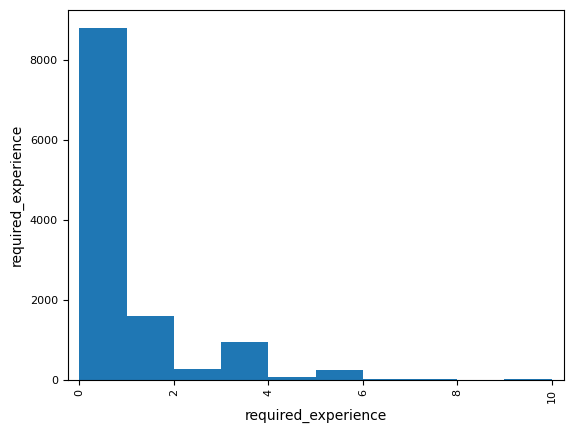

In [102]:
pd.plotting.scatter_matrix(df_sample[['salary_min','required_experience']])


Теперь проверим наличие зависимости зарплаты от уровня образования считая его ранговой переменной

Проранжируем уровень зарплаты и уровень образования

In [103]:
df_sample['education'].unique()

array(['Высшее', 'Среднее', 'Не указано', 'Среднее профессиональное',
       'Основное общее', 'Незаконченное высшее'], dtype=object)

In [104]:
edu_ranks_subst = {
    'Не указано':0,
    'Основное общее': 1,
    'Среднее':2,
    'Среднее профессиональное':3,
    'Незаконченное высшее':4,
    'Высшее':5,
  }

In [105]:
df_sample['edu_rank']  = df_sample['education'].replace(edu_ranks_subst).rank()
df_sample['salary_rank'] = df_sample['salary_min'].astype(int).rank()

In [106]:
df_sample[['edu_rank', 'salary_rank']]

,edu_rank,salary_rank
100731,10735.5,8322.0
57831,5405.0,2041.5
26054,2204.5,5876.0
9133,5405.0,6402.5
77727,2204.5,5140.5
...,...,...
116774,5405.0,9929.5
116149,7905.0,9001.0
73238,2204.5,8322.0
26492,2204.5,5332.5


In [108]:
df_rank = df_sample[['edu_rank','required_experience']].apply(lambda row: (row['edu_rank'],	row['required_experience']),axis=1).rank()
df_sample['dual_rank'] = df_rank

In [109]:
df_sample['dual_rank']

100731    10256.5
57831      5262.5
26054      1879.0
9133       5262.5
77727      1879.0
           ...   
116774     5262.5
116149     9294.5
73238      1879.0
26492      4290.0
35233      7296.5
Name: dual_rank, Length: 11931, dtype: float64

Вычислим коэффициент корреляции Спирмена

In [110]:
correlation_coefficient, p_value = stats.spearmanr(df_sample['salary_rank'], df_sample['edu_rank'])
correlation_coefficient


0.16398200576432193

Корреляция слабая положительная. Можно считать, что уровень нижней границы не зависит от уровня образования.

In [108]:
stats.spearmanr(df_sample['salary_rank'],df_sample['dual_rank']).statistic

0.17424314838329802

Наконец, проверим влияет ли факт наличия высшего образования на величину зарплаты.
Воспользуемся точечно биссериальной корреляцией

In [112]:

stats.pointbiserialr(df_sample['Высшее'], df_sample['salary_min'])


PointbiserialrResult(correlation=0.038786193578858326, pvalue=2.2578877476707366e-05)

In [113]:
stats.pointbiserialr(df_sample['Не указано'], df_sample['salary_min'])


PointbiserialrResult(correlation=-0.08511588549709108, pvalue=1.2419861152518975e-20)

Итак, нижняя граница зарплатной вилки практически не зависит ни от одного из рассмотренных признаков.

1. Может быть она зависит от профессии или от области деятельности?
Рассмотреть для каждой профессии в отдельности?
2. Взять среднюю зарплату (нижняя + верхняя)/2 ?


## ЗАДАНИЕ ДЛЯ САМОСТОЯТЕЛЬНОЙ РАБОТЫ
В соответствии со сформулированной итоговой задачей
1. сформировать выборку,
2. выполнить кодирование признаков,
3. проверить зависимость признаков.